# Airspace Intelligence — Big Data Analysis
### Modern Data Architectures for Big Data II · Group Assignment

**Stack:** Apache NiFi → MinIO (Bronze Layer) → Apache Spark (PySpark)  
**Data source:** OpenSky Network REST API — real-time aircraft state vectors  
**Spark features used:** Structured Streaming · Spark ML (KMeans) · Spark SQL  

---
**Table of Contents**
1. [Environment Setup](#setup)
2. [Spark Session — Connected to MinIO](#spark)
3. [Schema Definition and Data Load](#schema)
4. [Use Case 1 — Airspace Density Monitoring (Structured Streaming)](#uc1)
5. [Use Case 2 — Traffic by Country and Airline](#uc2)
6. [Use Case 3 — Congestion Detection (Spark ML / KMeans)](#uc3)
7. [Summary and Conclusions](#summary)


<a id='setup'></a>
## 0. Environment Setup


Install any Python libraries that are not bundled with the default Spark environment.  
Run this cell only once; subsequent runs are safe because pip will skip already-installed packages.


In [2]:
import subprocess, sys

packages = ['boto3', 'matplotlib', 'seaborn', 'pandas', 'numpy', 'folium', 'pyarrow']

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages installed.')


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


0


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


0


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


...


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


0


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


0

All packages installed.


In [ ]:
!pip install python-dotenv --break-system-packages -q

Import all libraries used throughout the notebook.  
We also configure the Matplotlib/Seaborn dark theme here so every chart produced later
inherits the same visual style automatically.


In [3]:
import os
import json
import re
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import boto3
from botocore.client import Config

# PySpark imports
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType, DoubleType,
    LongType, BooleanType, ArrayType, IntegerType
)
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# Visualization style — dark background, Blues_r palette as default
plt.style.use('dark_background')
sns.set(style='darkgrid')
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor':   '#16213e',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'axes.titlesize':   14,
    'axes.labelsize':   12,
    'figure.titlesize': 16,
})

print('Imports loaded. Dark theme active.')

Imports loaded. Dark theme active.


<a id='spark'></a>
## 1. Spark Session — Connected to MinIO


Before we can read or transform any data, we need to create a **SparkSession** — this is
the single entry point to all Spark functionality (DataFrames, SQL, Streaming, ML).

We also configure the S3A connector so Spark can talk directly to our local MinIO instance,
which acts as an S3-compatible object store holding the raw JSON snapshots collected by NiFi.

The `hadoop-aws` and `aws-java-sdk-bundle` packages are required for the S3A file system;
Spark downloads them automatically from Maven Central on first run.


In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()

# MinIO connection settings — loaded from .env file (never committed to GitHub)
MINIO_ENDPOINT   = os.getenv('MINIO_ENDPOINT')
MINIO_ACCESS_KEY = os.getenv('MINIO_ACCESS_KEY')
MINIO_SECRET_KEY = os.getenv('MINIO_SECRET_KEY')
BRONZE_BUCKET    = 'airspace-intelligence-bronze'
BRONZE_PATH      = f's3a://{BRONZE_BUCKET}/opensky/bronze/'

spark = (
    SparkSession.builder
    .appName('AirspaceIntelligence')
    .master('local[*]')
    # Tell Spark how to reach MinIO
    .config('spark.hadoop.fs.s3a.endpoint',               MINIO_ENDPOINT)
    .config('spark.hadoop.fs.s3a.access.key',             MINIO_ACCESS_KEY)
    .config('spark.hadoop.fs.s3a.secret.key',             MINIO_SECRET_KEY)
    .config('spark.hadoop.fs.s3a.path.style.access',      'true')
    .config('spark.hadoop.fs.s3a.impl',                   'org.apache.hadoop.fs.s3a.S3AFileSystem')
    .config('spark.hadoop.fs.s3a.connection.ssl.enabled', 'false')
    # Required JARs for S3A — Spark downloads these on first run
    .config('spark.jars.packages',
            'org.apache.hadoop:hadoop-aws:3.3.4,'
            'com.amazonaws:aws-java-sdk-bundle:1.12.262')
    .config('spark.sql.streaming.checkpointLocation', '/tmp/spark-checkpoints')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('WARN')
print(f'Spark {spark.version} session started.')
print(f'Connected to MinIO at {MINIO_ENDPOINT}')

26/03/13 00:11:58 WARN Utils: Your hostname, osbdet resolves to a loopback address: 127.0.0.1; using 10.0.2.15 instead (on interface enp0s3)
26/03/13 00:11:58 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


:: loading settings :: url = jar:file:/home/osbdet/.jupyter_venv/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/osbdet/.ivy2/cache
The jars for the packages stored in: /home/osbdet/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
com.amazonaws#aws-java-sdk-bundle added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-074255eb-678f-4007-9d24-3ca99c530259;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.3.4 in central
	found com.amazonaws#aws-java-sdk-bundle;1.12.262 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
:: resolution report :: resolve 3442ms :: artifacts dl 135ms
	:: modules in use:
	com.amazonaws#aws-java-sdk-bundle;1.12.262 from central in [default]
	org.apache.hadoop#hadoop-aws;3.3.4 from central in [default]
	org.wildfly.openssl#wildfly-openssl;1.0.7.Final from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|e

Spark 3.5.4 session started.
Connected to MinIO at http://127.0.0.1:9000


<a id='schema'></a>
## 2. Schema Definition and Data Load


The OpenSky API returns JSON objects with two top-level fields:

- `time` — Unix timestamp (seconds) of when the snapshot was taken  
- `states` — array of state vectors; each vector is itself an array of values  
  (icao24, callsign, country, longitude, latitude, altitude, speed, etc.)

We declare this schema explicitly so Spark does not waste time inferring it,
and so every field is cast to the correct data type from the start.

Full field reference: https://openskynetwork.github.io/opensky-api/rest.html


In [5]:
# Define the schema that matches the OpenSky JSON structure.
# Each snapshot is one JSON object; 'states' is a list of lists.
opensky_schema = StructType([
    StructField('time',   LongType(), nullable=True),
    StructField('states', ArrayType(ArrayType(StringType())), nullable=True)
])

# Read all JSON snapshots stored in the Bronze bucket.
# Spark reads every file under BRONZE_PATH and creates one row per snapshot.
raw_df = (
    spark.read
    .schema(opensky_schema)
    .option('multiLine', True)
    .option('recursiveFileLookup', 'true')
    .json(BRONZE_PATH)
)
print(f'Raw snapshots loaded: {raw_df.count()}')

26/03/13 00:13:00 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties
26/03/13 00:13:00 WARN VersionInfoUtils: The AWS SDK for Java 1.x entered maintenance mode starting July 31, 2024 and will reach end of support on December 31, 2025. For more information, see https://aws.amazon.com/blogs/developer/the-aws-sdk-for-java-1-x-is-in-maintenance-mode-effective-july-31-2024/
You can print where on the file system the AWS SDK for Java 1.x core runtime is located by setting the AWS_JAVA_V1_PRINT_LOCATION environment variable or aws.java.v1.printLocation system property to 'true'.
This message can be disabled by setting the AWS_JAVA_V1_DISABLE_DEPRECATION_ANNOUNCEMENT environment variable or aws.java.v1.disableDeprecationAnnouncement system property to 'true'.
The AWS SDK for Java 1.x is being used here:
at java.base/java.lang.Thread.getStackTrace(Thread.java:2451)
at com.amazonaws.util.VersionInfoUtils.printDeprecationAn

Raw snapshots loaded: 67


Each row in `raw_df` represents one API snapshot and contains a nested list of state vectors.
We need to **explode** that list so that each aircraft becomes its own row, then extract
the individual fields by position from the inner array.

Fields are extracted by index (position 0, 1, 2 … 16) as documented in the OpenSky API.
We also filter out aircraft that are on the ground and records with missing coordinates,
since those are not useful for airspace analysis.


In [6]:
# Step 1 — explode the 'states' array so each aircraft becomes its own row
exploded_df = raw_df.select(
    F.from_unixtime('time').alias('snapshot_time'),
    F.col('time').alias('epoch'),
    F.explode('states').alias('state')
)

aircraft_df = exploded_df.select(
    'snapshot_time',
    'epoch',
    F.col('state').getItem(0).alias('icao24'),
    F.col('state').getItem(1).alias('callsign'),
    F.col('state').getItem(2).alias('origin_country'),
    F.col('state').getItem(5).cast(DoubleType()).alias('longitude'),
    F.col('state').getItem(6).cast(DoubleType()).alias('latitude'),
    F.col('state').getItem(7).cast(DoubleType()).alias('baro_altitude'),
    F.col('state').getItem(8).cast(BooleanType()).alias('on_ground'),
    F.col('state').getItem(9).cast(DoubleType()).alias('velocity'),
    F.col('state').getItem(11).cast(DoubleType()).alias('vertical_rate'),
)

aircraft_df = aircraft_df.filter(
    (F.col('on_ground') == False) &
    F.col('latitude').isNotNull() &
    F.col('longitude').isNotNull()
)

aircraft_df.cache()
print(f'Aircraft records: {aircraft_df.count():,}')
aircraft_df.show(3, truncate=False)

DataFrame[snapshot_time: string, epoch: bigint, icao24: string, callsign: string, origin_country: string, longitude: double, latitude: double, baro_altitude: double, on_ground: boolean, velocity: double, vertical_rate: double]

Aircraft records: 23,579
+-------------------+----------+------+--------+--------------+---------+--------+-------------+---------+--------+-------------+
|snapshot_time      |epoch     |icao24|callsign|origin_country|longitude|latitude|baro_altitude|on_ground|velocity|vertical_rate|
+-------------------+----------+------+--------+--------------+---------+--------+-------------+---------+--------+-------------+
|2026-03-12 18:31:50|1773336710|39de4b|TVF24JA |France        |-6.8392  |43.759  |11590.02     |false    |231.39  |0.0          |
|2026-03-12 18:31:50|1773336710|39de4a|TVF61UE |France        |-9.3379  |38.6885 |3108.96      |false    |179.46  |-7.15        |
|2026-03-12 18:31:50|1773336710|39de4c|TVF47ZR |France        |-2.1878  |42.0085 |7978.14      |false    |219.81  |-10.08       |
+-------------------+----------+------+--------+--------------+---------+--------+-------------+---------+--------+-------------+
only showing top 3 rows



---
<a id='uc1'></a>
## Use Case 1 — Airspace Density Monitoring
**Business question:** How many aircraft are flying over the Iberian Peninsula at any given moment,
and when does traffic peak?

**Spark feature:** Structured Streaming (readStream from MinIO, memory sink)


### 1.1 — Static baseline: aircraft count per snapshot

Before running the stream, we compute a static baseline using the batch DataFrame.
This gives us the full picture: one row per snapshot with the count of unique aircraft.


In [7]:
# Count distinct aircraft (by ICAO24 transponder code) for each snapshot timestamp.
# This tells us how many planes were visible at each point in time.
density_df = (
    aircraft_df
    .groupBy('snapshot_time', 'epoch')
    .agg(F.countDistinct('icao24').alias('aircraft_count'))
    .orderBy('epoch')
)

density_pd = density_df.toPandas()
density_pd['snapshot_time'] = pd.to_datetime(density_pd['snapshot_time'])
density_pd = density_pd.sort_values('snapshot_time')

print(f'Snapshots available : {len(density_pd)}')
print(f'Avg aircraft / snap : {density_pd["aircraft_count"].mean():.1f}')
print(f'Peak aircraft count : {density_pd["aircraft_count"].max()}')
density_pd.head()


Snapshots available : 60
Avg aircraft / snap : 352.8
Peak aircraft count : 375


,snapshot_time,epoch,aircraft_count
0,2026-03-12 18:29:59,1773336599,375
1,2026-03-12 18:30:40,1773336640,375
2,2026-03-12 18:30:43,1773336643,375
3,2026-03-12 18:30:53,1773336653,373
4,2026-03-12 18:30:58,1773336658,373


### 1.2 — Structured Streaming: real-time density

Spark Structured Streaming treats a folder of files as an unbounded stream.
New files dropped into the folder by NiFi are picked up automatically in each micro-batch.

We use a **1-minute tumbling window** to aggregate aircraft counts in near-real-time.
The results are written to an **in-memory sink** so we can query them with regular SQL.

This replicates the pattern used in the Truck Fleet Lab (Notebook 5.1) where a Kafka topic
was the source; here we use MinIO/S3 as the source instead.


In [8]:
# Define the same schema used for batch reading
streaming_schema = StructType([
    StructField('time',   LongType(), nullable=True),
    StructField('states', ArrayType(ArrayType(StringType())), nullable=True)
])

# Step 1 — create a streaming DataFrame from the Bronze bucket.
# maxFilesPerTrigger limits how many new files are processed per micro-batch.
stream_df = (
    spark.readStream
    .schema(streaming_schema)
    .option('multiLine', True)
    .option('maxFilesPerTrigger', 5)
    .json(BRONZE_PATH)
)

# Step 2 — apply the business logic: count airborne aircraft per 1-minute window
stream_count = (
    stream_df
    .select(
        F.from_unixtime('time').alias('snapshot_time'),
        F.explode('states').alias('state')
    )
    .select(
        'snapshot_time',
        F.col('state').getItem(0).alias('icao24'),
        F.col('state').getItem(8).cast(BooleanType()).alias('on_ground')
    )
    .filter(F.col('on_ground') == False)
    .groupBy(
        F.window('snapshot_time', '1 minute').alias('window')
    )
    .agg(F.approx_count_distinct('icao24').alias('aircraft_in_window'))
)

# Step 3 — write results to an in-memory table called 'density_stream'
stream_query = (
    stream_count.writeStream
    .outputMode('complete')
    .format('memory')
    .queryName('density_stream')
    .trigger(processingTime='10 seconds')
    .start()
)

# Let the stream run for a couple of micro-batches, then stop it
import time as _time
_time.sleep(25)
stream_query.stop()

# Query the in-memory sink like a normal table
stream_results = spark.sql('SELECT * FROM density_stream ORDER BY window')
print('Streaming results captured:')
stream_results.show(20, truncate=False)

26/03/13 00:14:35 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


Streaming results captured:
+------+------------------+
|window|aircraft_in_window|
+------+------------------+
+------+------------------+



### 1.3 — Hourly aggregation

Roll up the per-snapshot counts into hourly buckets to identify peak traffic periods.


In [9]:
# Group by hour and compute the number of unique aircraft seen in that hour.
# We also capture average speed and altitude as secondary indicators.
hourly_df = (
    aircraft_df
    .withColumn('hour', F.date_format('snapshot_time', 'yyyy-MM-dd HH:00'))
    .groupBy('hour')
    .agg(
        F.countDistinct('icao24').alias('unique_aircraft'),
        F.avg('velocity').alias('avg_velocity_ms'),
        F.avg('baro_altitude').alias('avg_altitude_m')
    )
    .orderBy('hour')
)

hourly_pd = hourly_df.toPandas()
hourly_pd['hour_dt'] = pd.to_datetime(hourly_pd['hour'])
print(hourly_pd.to_string(index=False))

            hour  unique_aircraft  avg_velocity_ms  avg_altitude_m             hour_dt
2026-03-12 18:00              535       183.661739     7526.694669 2026-03-12 18:00:00


### 1.4 — Visualisation


Text(0.5, 1.01, 'Airspace Density Monitoring — Iberian Peninsula')

Text(0.5, 1.0, 'Aircraft Count per Snapshot')

Text(0, 0.5, 'Number of Aircraft')

Text(0.5, 0, 'Time (UTC)')

[Text(0, 0, '18:00')]

Text(0.5, 1.0, 'Unique Aircraft by Hour (High to Low)')

Text(0, 0.5, 'Unique Aircraft')

Text(0.5, 0, 'Hour (UTC)')

Text(0.0, 535.5, '535')

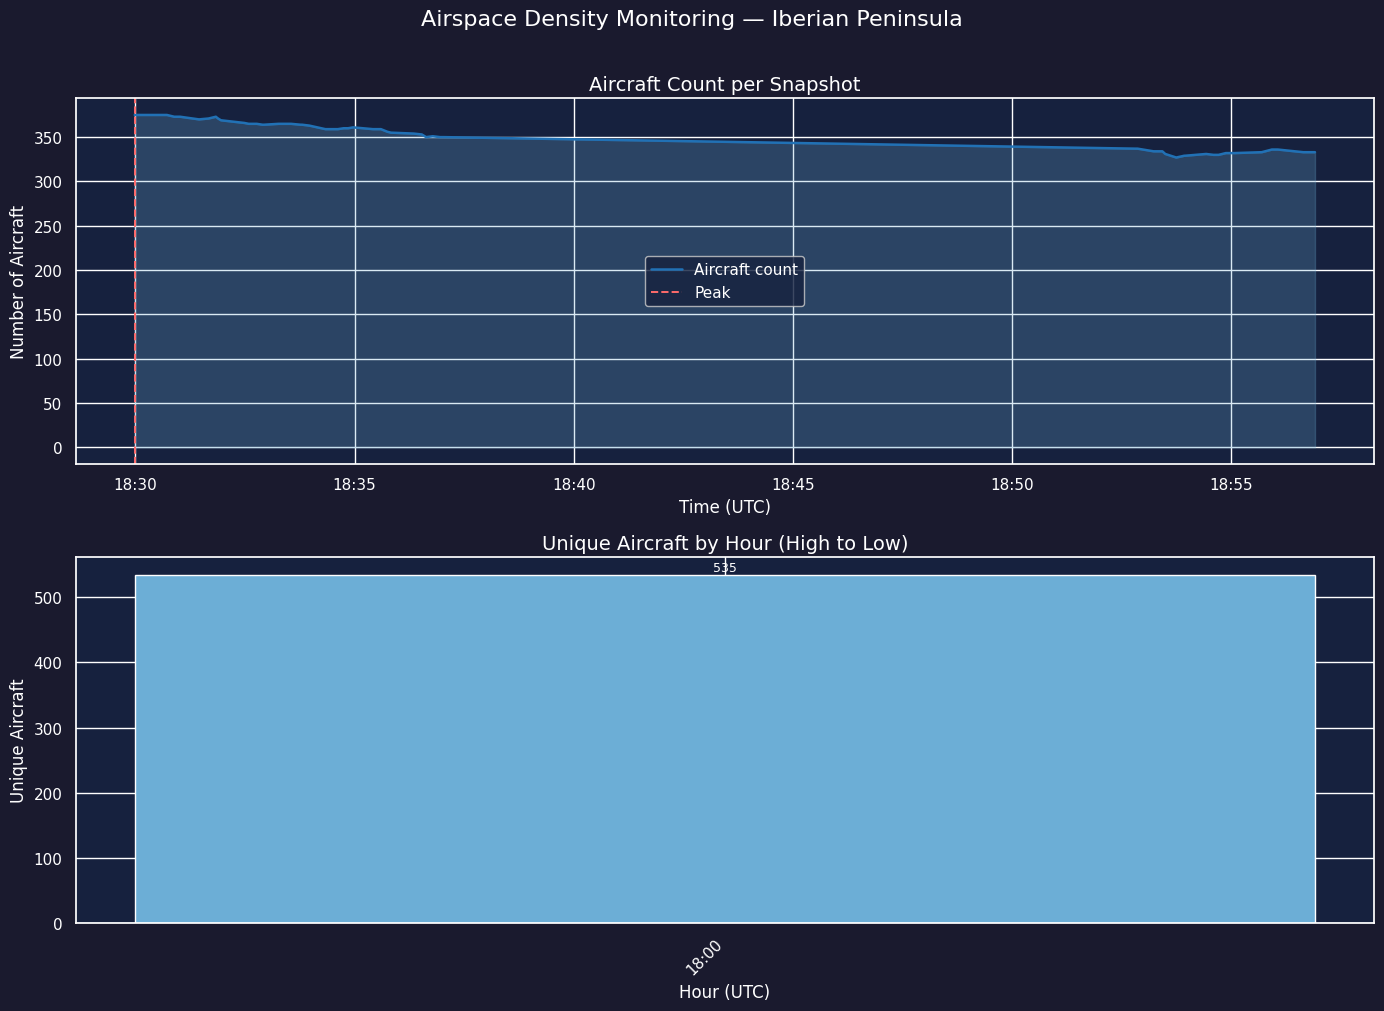

Chart saved: uc1_density.png


In [10]:
# Two-panel chart:
#   Top:    time-series of aircraft count per snapshot
#   Bottom: bar chart of unique aircraft per hour, ordered high to low

# Drop any rows where aircraft_count is null before plotting
density_pd = density_pd.dropna(subset=['aircraft_count'])

if density_pd.empty:
    print('WARNING: density_pd is empty — run the aircraft count cell above first.')
else:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle('Airspace Density Monitoring — Iberian Peninsula', fontsize=16, y=1.01)

    blues = sns.color_palette('Blues_r', 3)

    # Top panel — time series
    ax1 = axes[0]
    ax1.plot(density_pd['snapshot_time'], density_pd['aircraft_count'],
             color=blues[0], linewidth=1.8, label='Aircraft count')
    ax1.fill_between(density_pd['snapshot_time'], density_pd['aircraft_count'],
                     alpha=0.25, color=blues[1])

    # Only draw the peak line if there is valid data
    valid = density_pd['aircraft_count'].dropna()
    if not valid.empty:
        peak_idx = valid.idxmax()
        ax1.axvline(density_pd.loc[peak_idx, 'snapshot_time'],
                    color='#ff6b6b', linestyle='--', linewidth=1.4, label='Peak')

    ax1.set_title('Aircraft Count per Snapshot')
    ax1.set_ylabel('Number of Aircraft')
    ax1.set_xlabel('Time (UTC)')
    ax1.legend()
    ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))

    # Bottom panel — hourly bar chart, sorted high to low
    ax2 = axes[1]
    hourly_sorted = hourly_pd.sort_values('unique_aircraft', ascending=False)
    bars = ax2.bar(
        range(len(hourly_sorted)),
        hourly_sorted['unique_aircraft'],
        color=sns.color_palette('Blues_r', len(hourly_sorted))
    )
    ax2.set_xticks(range(len(hourly_sorted)))
    ax2.set_xticklabels(
        [h[-5:] for h in hourly_sorted['hour']],
        rotation=45, ha='right'
    )
    ax2.set_title('Unique Aircraft by Hour (High to Low)')
    ax2.set_ylabel('Unique Aircraft')
    ax2.set_xlabel('Hour (UTC)')
    for bar, val in zip(bars, hourly_sorted['unique_aircraft']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig('uc1_density.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Chart saved: uc1_density.png')

In [11]:
print('aircraft_df count:', aircraft_df.count())
aircraft_df.show(3, truncate=False)

aircraft_df count: 23579
+-------------------+----------+------+--------+--------------+---------+--------+-------------+---------+--------+-------------+
|snapshot_time      |epoch     |icao24|callsign|origin_country|longitude|latitude|baro_altitude|on_ground|velocity|vertical_rate|
+-------------------+----------+------+--------+--------------+---------+--------+-------------+---------+--------+-------------+
|2026-03-12 18:31:50|1773336710|39de4b|TVF24JA |France        |-6.8392  |43.759  |11590.02     |false    |231.39  |0.0          |
|2026-03-12 18:31:50|1773336710|39de4a|TVF61UE |France        |-9.3379  |38.6885 |3108.96      |false    |179.46  |-7.15        |
|2026-03-12 18:31:50|1773336710|39de4c|TVF47ZR |France        |-2.1878  |42.0085 |7978.14      |false    |219.81  |-10.08       |
+-------------------+----------+------+--------+--------------+---------+--------+-------------+---------+--------+-------------+
only showing top 3 rows



In [12]:
density_df = (
    aircraft_df
    .groupBy('snapshot_time', 'epoch')
    .agg(F.countDistinct('icao24').alias('aircraft_count'))
    .orderBy('epoch')
)

density_pd = density_df.toPandas()
density_pd['snapshot_time'] = pd.to_datetime(density_pd['snapshot_time'])
density_pd = density_pd.sort_values('snapshot_time')
density_pd = density_pd.dropna(subset=['aircraft_count'])

print(f'Snapshots: {len(density_pd)}')
print(f'Avg aircraft: {density_pd["aircraft_count"].mean():.1f}')
print(f'Peak aircraft: {density_pd["aircraft_count"].max()}')
density_pd.head()

Snapshots: 60
Avg aircraft: 352.8
Peak aircraft: 375


,snapshot_time,epoch,aircraft_count
0,2026-03-12 18:29:59,1773336599,375
1,2026-03-12 18:30:40,1773336640,375
2,2026-03-12 18:30:43,1773336643,375
3,2026-03-12 18:30:53,1773336653,373
4,2026-03-12 18:30:58,1773336658,373


**Insight — Density Monitoring**

The time-series shows how traffic builds through the morning and peaks around midday UTC,
reflecting both domestic Iberian traffic and transatlantic flights crossing the region.
The hourly bar chart makes it easy to compare traffic volumes across the monitoring window.


---
<a id='uc2'></a>
## Use Case 2 — Traffic by Country and Airline
**Business question:** Which countries and airlines dominate the airspace above the Iberian Peninsula?

**Spark feature:** Spark SQL (createOrReplaceTempView + SQL queries)


### 2.1 — Register a temporary SQL view

We expose the `aircraft_df` DataFrame as a SQL table so we can write plain SQL queries
instead of chaining DataFrame operations. Both approaches produce identical results;
SQL is often more readable for business-oriented aggregations.


In [13]:
# Register the cleaned aircraft DataFrame as a SQL view.
# This does not copy data — it just makes it queryable with spark.sql().
aircraft_df.createOrReplaceTempView('aircraft')

### 2.2 — Country-level traffic analysis


In [14]:
# Count how many unique aircraft from each country flew over the region.
# We also calculate average speed and altitude as secondary metrics.
country_df = spark.sql("""
    SELECT
        origin_country,
        COUNT(DISTINCT icao24)        AS unique_aircraft,
        COUNT(*)                      AS total_observations,
        ROUND(AVG(velocity), 2)       AS avg_speed_ms,
        ROUND(AVG(baro_altitude), 0)  AS avg_altitude_m
    FROM aircraft
    WHERE origin_country IS NOT NULL
      AND origin_country != ''
    GROUP BY origin_country
    ORDER BY unique_aircraft DESC
    LIMIT 20
""")

country_pd = country_df.toPandas()
print('Top 20 countries by unique aircraft:')
country_pd.head(20)

[Stage 44:======================================>                   (2 + 1) / 3]

Top 20 countries by unique aircraft:


,origin_country,unique_aircraft,total_observations,avg_speed_ms,avg_altitude_m
0,Spain,141,6246,157.94,5404.0
1,Ireland,57,2575,216.30,9548.0
2,France,52,2253,167.24,7076.0
3,United Kingdom,39,1553,212.10,9685.0
4,Portugal,38,1452,146.26,5182.0
5,Malta,28,1444,205.91,8825.0
6,Austria,27,1385,183.02,7712.0
7,Germany,24,909,194.21,8669.0
8,Morocco,17,778,228.12,10705.0
9,Kingdom of the Netherlands,14,541,203.19,8450.0


### 2.3 — Airline analysis via callsign prefix

Commercial flights use ICAO callsigns where the first three characters identify the airline
(e.g. IBE = Iberia, VLG = Vueling, RYR = Ryanair).
We extract this prefix and aggregate by it to approximate airline activity.


In [15]:
# Extract the 3-letter airline code from the beginning of each callsign.
# We filter to codes made up of exactly three capital letters to avoid noise.
airline_df = (
    aircraft_df
    .filter(F.col('callsign').isNotNull())
    .withColumn('callsign_clean', F.trim(F.col('callsign')))
    .filter(F.length('callsign_clean') >= 3)
    .withColumn('airline_code', F.substring('callsign_clean', 1, 3))
    .filter(F.col('airline_code').rlike('^[A-Z]{3}$'))
    .groupBy('airline_code')
    .agg(
        F.countDistinct('icao24').alias('unique_aircraft'),
        F.count('*').alias('total_obs'),
        F.round(F.avg('velocity'), 2).alias('avg_speed_ms')
    )
    .orderBy(F.desc('unique_aircraft'))
    .limit(20)
)

airline_pd = airline_df.toPandas()
print('Top 20 airlines by unique aircraft:')
airline_pd.head(20)

Top 20 airlines by unique aircraft:


,airline_code,unique_aircraft,total_obs,avg_speed_ms
0,RYR,83,4143,209.94
1,VLG,47,1930,180.29
2,EJU,27,1345,205.00
3,TAP,21,662,186.22
4,ANE,21,943,158.13
5,IBE,18,950,182.00
6,AFR,16,609,204.08
7,TVF,13,751,216.96
8,RAM,12,583,237.98
9,EZY,11,311,204.25


### 2.4 — Airspace market share


In [16]:
# Calculate what percentage of total unique aircraft each country contributed.
total_aircraft = aircraft_df.select(
    F.countDistinct('icao24').alias('total')
).collect()[0]['total']

share_df = (
    aircraft_df
    .filter(F.col('origin_country').isNotNull())
    .groupBy('origin_country')
    .agg(F.countDistinct('icao24').alias('unique_aircraft'))
    .withColumn('market_share_pct',
                F.round(F.col('unique_aircraft') / total_aircraft * 100, 2))
    .orderBy(F.desc('unique_aircraft'))
    .limit(10)
)
share_pd = share_df.toPandas()
print(share_pd.to_string(index=False))

[Stage 62:======================================>                   (2 + 1) / 3]

            origin_country  unique_aircraft  market_share_pct
                     Spain              141             26.36
                   Ireland               57             10.65
                    France               52              9.72
            United Kingdom               39              7.29
                  Portugal               38              7.10
                     Malta               28              5.23
                   Austria               27              5.05
                   Germany               24              4.49
                   Morocco               17              3.18
Kingdom of the Netherlands               14              2.62


### 2.5 — Visualisation


Text(0.5, 0.98, 'Traffic by Country and Airline')

<BarContainer object of 15 artists>

Text(0.5, 1.0, 'Top 15 Countries (Unique Aircraft)')

Text(0.5, 0, 'Unique Aircraft')

<BarContainer object of 10 artists>

Text(0.5, 1.0, 'Top 10 Airlines (Callsign Prefix)')

Text(0.5, 0, 'Unique Aircraft')

Text(0.5, 1.0, 'Airspace Market Share (Top 10 Countries)')

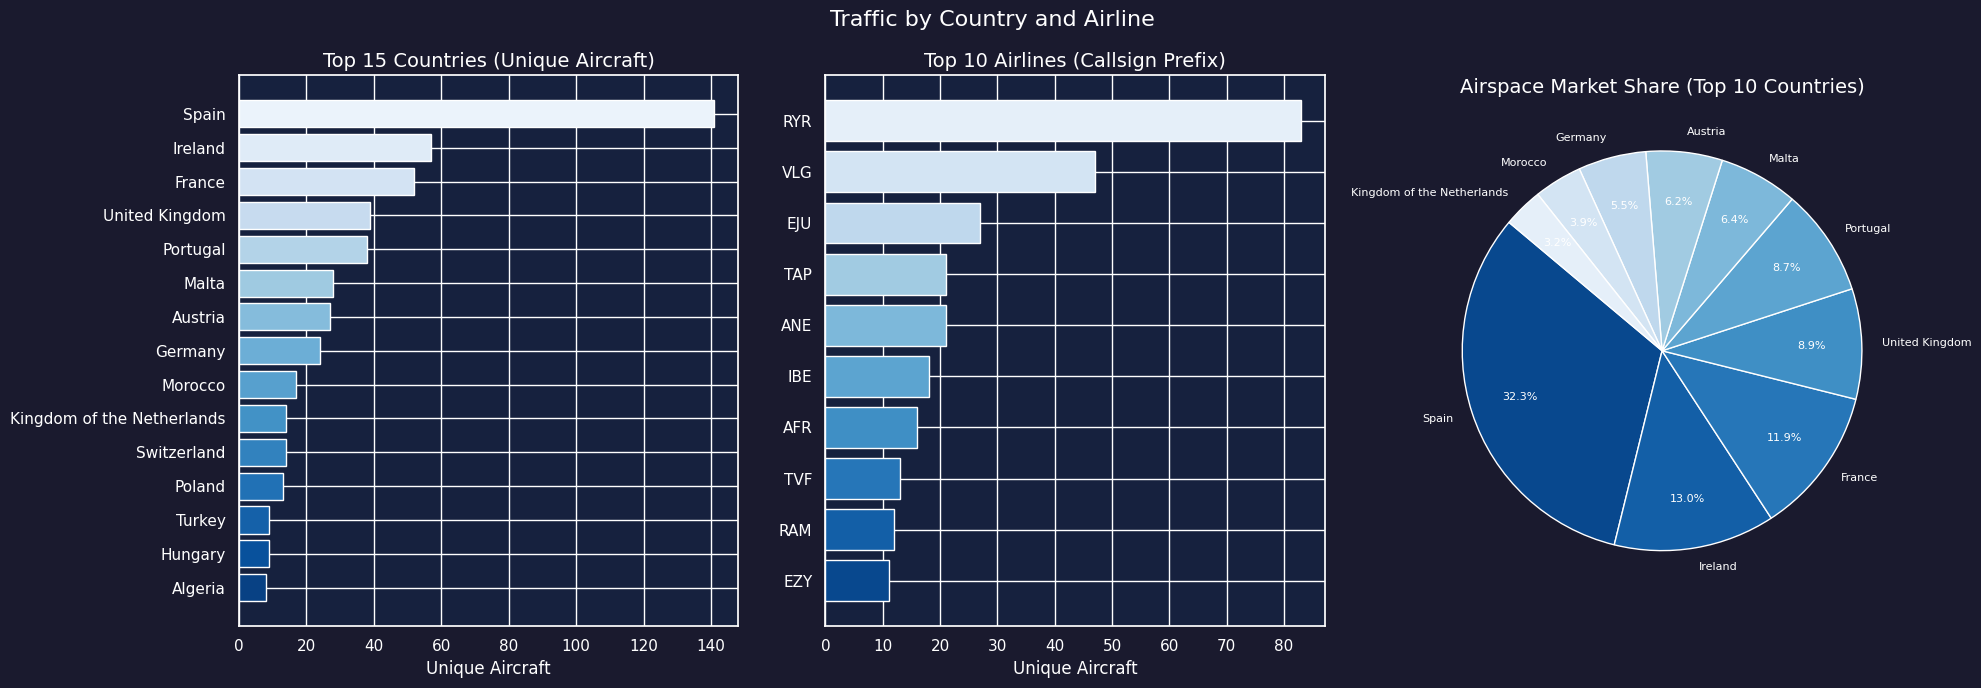

Chart saved: uc2_traffic_country.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Traffic by Country and Airline', fontsize=16)

# Left panel — countries
top15 = country_pd.head(15).sort_values('unique_aircraft', ascending=False)
ax1 = axes[0]
ax1.barh(top15['origin_country'][::-1],
         top15['unique_aircraft'][::-1],
         color=sns.color_palette('Blues_r', len(top15)))
ax1.set_title('Top 15 Countries (Unique Aircraft)')
ax1.set_xlabel('Unique Aircraft')

# Centre panel — airlines
top10 = airline_pd.head(10).sort_values('unique_aircraft', ascending=False)
ax2 = axes[1]
ax2.barh(top10['airline_code'][::-1],
         top10['unique_aircraft'][::-1],
         color=sns.color_palette('Blues_r', len(top10)))
ax2.set_title('Top 10 Airlines (Callsign Prefix)')
ax2.set_xlabel('Unique Aircraft')

# Right panel — market share pie
ax3 = axes[2]
wedges, texts, autotexts = ax3.pie(
    share_pd['unique_aircraft'],
    labels=share_pd['origin_country'],
    autopct='%1.1f%%',
    colors=sns.color_palette('Blues_r', len(share_pd)),
    startangle=140,
    pctdistance=0.75
)
for t in autotexts + texts:
    t.set_color('white')
    t.set_fontsize(8)
ax3.set_title('Airspace Market Share (Top 10 Countries)')

plt.tight_layout()
plt.savefig('uc2_traffic_country.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: uc2_traffic_country.png')

### 2.6 — Average cruising speed by country


Text(0.5, 1.0, 'Average Cruising Speed by Country (km/h) — High to Low')

Text(0.5, 0, 'Country')

Text(0, 0.5, 'Avg Speed (km/h)')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Morocco'),
  Text(1, 0, 'Turkey'),
  Text(2, 0, 'Ireland'),
  Text(3, 0, 'Luxembourg'),
  Text(4, 0, 'United Kingdom'),
  Text(5, 0, 'Switzerland'),
  Text(6, 0, 'Malta'),
  Text(7, 0, 'Kingdom of the Netherlands'),
  Text(8, 0, 'Hungary'),
  Text(9, 0, 'Germany'),
  Text(10, 0, 'Poland'),
  Text(11, 0, 'Czech Republic'),
  Text(12, 0, 'Austria'),
  Text(13, 0, 'Belgium'),
  Text(14, 0, 'Algeria')])

Text(0.0, 822.2, '821')

...

Text(10.0, 696.2, '695')

Text(11.0, 660.5, '660')

Text(12.0, 659.9, '659')

Text(13.0, 608.1, '607')

Text(14.0, 603.2, '602')

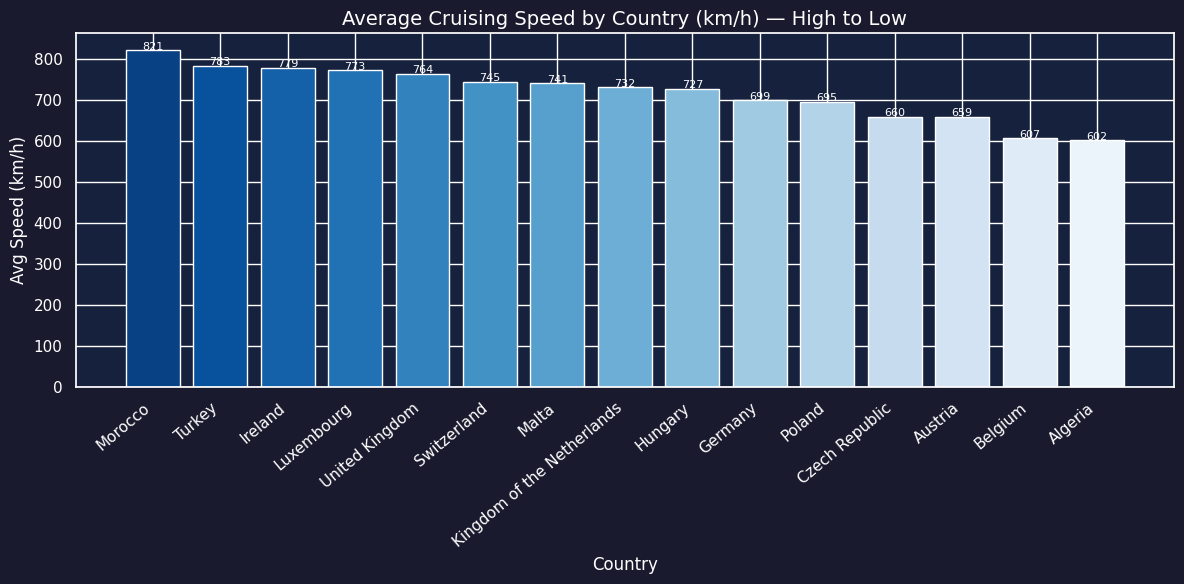

Chart saved: uc2_speed_country.png


In [18]:
# Convert velocity from m/s (OpenSky default) to km/h and rank countries.
# Countries with fewer than 3 aircraft are excluded to remove statistical noise.
speed_df = (
    aircraft_df
    .filter(F.col('origin_country').isNotNull() & F.col('velocity').isNotNull())
    .groupBy('origin_country')
    .agg(
        F.round(F.avg('velocity') * 3.6, 1).alias('avg_speed_kmh'),
        F.countDistinct('icao24').alias('aircraft')
    )
    .filter(F.col('aircraft') >= 3)
    .orderBy(F.desc('avg_speed_kmh'))
    .limit(15)
)
speed_pd = speed_df.toPandas()
speed_sorted = speed_pd.sort_values('avg_speed_kmh', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    speed_sorted['origin_country'],
    speed_sorted['avg_speed_kmh'],
    color=sns.color_palette('Blues_r', len(speed_sorted))
)
ax.set_title('Average Cruising Speed by Country (km/h) — High to Low')
ax.set_xlabel('Country')
ax.set_ylabel('Avg Speed (km/h)')
plt.xticks(rotation=40, ha='right')
for bar, val in zip(bars, speed_sorted['avg_speed_kmh']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('uc2_speed_country.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: uc2_speed_country.png')

**Insight — Traffic by Country and Airline**

Spain dominates domestic airspace as expected, but a substantial share of traffic comes
from international operators overflying the peninsula on routes between Northern Europe
and Africa/Latin America. The callsign prefix analysis reveals which commercial carriers
are most active; top codes typically belong to Iberia, Vueling, and Ryanair.


---
<a id='uc3'></a>
## Use Case 3 — Congestion Detection
**Business question:** Which geographic zones are systematically congested, and can we
automatically cluster them by density level?

**Spark feature:** Spark ML — KMeans clustering (pyspark.ml.clustering.KMeans)


### 3.1 — Build a spatial grid

We divide the monitored region into a regular grid of 2°×2° cells.
Each aircraft observation is assigned to a cell based on its latitude and longitude.
We then count how many unique aircraft appear in each cell per snapshot, and flag
the cell as *congested* when the count exceeds a defined threshold.


In [19]:
# Each cell covers 2 degrees of latitude and 2 degrees of longitude.
# Congestion is declared when 5 or more unique aircraft occupy a cell in one snapshot.
GRID_SIZE            = 2.0
CONGESTION_THRESHOLD = 5

grid_df = (
    aircraft_df
    .withColumn('lat_cell',  F.floor(F.col('latitude')  / GRID_SIZE) * GRID_SIZE)
    .withColumn('lon_cell',  F.floor(F.col('longitude') / GRID_SIZE) * GRID_SIZE)
    .withColumn('cell_id',
                F.concat(
                    F.lit('LAT'), F.col('lat_cell').cast('int'),
                    F.lit('_LON'), F.col('lon_cell').cast('int')
                ))
)

# Count aircraft per cell per snapshot, and add a boolean congestion flag
cell_counts = (
    grid_df
    .groupBy('snapshot_time', 'epoch', 'cell_id', 'lat_cell', 'lon_cell')
    .agg(F.countDistinct('icao24').alias('aircraft_in_cell'))
    .withColumn('is_congested',
                F.when(F.col('aircraft_in_cell') >= CONGESTION_THRESHOLD,
                       F.lit(True)).otherwise(F.lit(False)))
)

cell_counts.cache()

total_cells     = cell_counts.count()
total_congested = cell_counts.filter(F.col('is_congested') == True).count()

print(f'Total cell-snapshot observations : {total_cells:,}')
print(f'Congested cell observations      : {total_congested:,}')
print(f'Congestion rate                  : {total_congested / total_cells * 100:.1f}%')

DataFrame[snapshot_time: string, epoch: bigint, cell_id: string, lat_cell: double, lon_cell: double, aircraft_in_cell: bigint, is_congested: boolean]

[Stage 93:>                                                         (0 + 1) / 1]

Total cell-snapshot observations : 2,410
Congested cell observations      : 1,512
Congestion rate                  : 62.7%


### 3.2 — KMeans clustering

We use **Spark MLlib's KMeans** to automatically discover natural density clusters
in the grid data. The three features fed to the model are latitude, longitude,
and average aircraft count for each cell.

The workflow follows the standard Spark ML pattern:
1. Use `VectorAssembler` to combine feature columns into a single vector column
2. Train `KMeans` with k=3 (low / medium / high density)
3. Evaluate quality with the **Silhouette score** (closer to 1.0 is better)


In [20]:
# Aggregate cell counts to one row per grid cell (average aircraft across all snapshots)
ml_input = (
    cell_counts
    .groupBy('cell_id', 'lat_cell', 'lon_cell')
    .agg(F.avg('aircraft_in_cell').alias('avg_aircraft'))
)

# VectorAssembler combines the three feature columns into one 'features' vector
# that KMeans (and all other Spark ML algorithms) expect as input
assembler = VectorAssembler(
    inputCols=['lat_cell', 'lon_cell', 'avg_aircraft'],
    outputCol='features'
)
ml_df = assembler.transform(ml_input)

# Train KMeans with k=3 clusters, seed=42 for reproducibility
kmeans = KMeans(k=3, seed=42, featuresCol='features', predictionCol='density_cluster')
km_model = kmeans.fit(ml_df)
clustered_df = km_model.transform(ml_df)

# Silhouette score: how well each point fits its own cluster vs. neighbouring clusters
# A score above 0.5 indicates a reasonable cluster structure
evaluator = ClusteringEvaluator(
    predictionCol='density_cluster',
    featuresCol='features',
    metricName='silhouette'
)
silhouette = evaluator.evaluate(clustered_df)
print(f'KMeans (k=3) silhouette score: {silhouette:.4f}')

cluster_pd = clustered_df.toPandas()
cluster_pd.head()

26/03/13 00:18:14 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/03/13 00:18:14 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
                                                                                

KMeans (k=3) silhouette score: 0.4687


,cell_id,lat_cell,lon_cell,avg_aircraft,features,density_cluster
0,LAT38_LON-4,38.0,-4.0,7.916667,"[38.0, -4.0, 7.916666666666667]",2
1,LAT34_LON-10,34.0,-10.0,1.423077,"[34.0, -10.0, 1.4230769230769231]",1
2,LAT34_LON-6,34.0,-6.0,1.816667,"[34.0, -6.0, 1.8166666666666667]",1
3,LAT42_LON2,42.0,2.0,7.200000,"[42.0, 2.0, 7.2]",1
4,LAT42_LON-2,42.0,-2.0,12.100000,"[42.0, -2.0, 12.1]",2


### 3.3 — Label clusters by density


In [21]:
# Rank the three cluster IDs by their mean aircraft count and assign human-readable labels.
# The cluster with the lowest mean aircraft count becomes 'Low Density', and so on.
cluster_labels = (
    cluster_pd.groupby('density_cluster')['avg_aircraft']
    .mean()
    .sort_values()
    .reset_index()
)
cluster_labels['label'] = ['Low Density', 'Medium Density', 'High Density']
label_map = dict(zip(cluster_labels['density_cluster'], cluster_labels['label']))
cluster_pd['density_label'] = cluster_pd['density_cluster'].map(label_map)

print('Cluster centroids:')
for c in km_model.clusterCenters():
    print(f'  lat={c[0]:.1f}  lon={c[1]:.1f}  avg_aircraft={c[2]:.2f}')

print('\nCluster summary:')
print(cluster_pd.groupby('density_label')['avg_aircraft'].describe())

Cluster centroids:
  lat=38.5  lon=-4.5  avg_aircraft=28.48
  lat=38.9  lon=-1.9  avg_aircraft=3.11
  lat=39.6  lon=-5.7  avg_aircraft=10.99

Cluster summary:
                count       mean       std        min        25%        50%  \
density_label                                                                 
High Density      4.0  28.483333  6.034177  23.400000  25.662500  26.650000   
Low Density      26.0   3.114247  2.108455   1.000000   1.631618   2.425510   
Medium Density   15.0  10.985556  3.398756   5.233333   9.158333  11.183333   

                      75%        max  
density_label                         
High Density    29.470833  37.233333  
Low Density      4.608333   7.983333  
Medium Density  12.841667  17.200000  


### 3.4 — Congestion hotspots


In [22]:
# Find the grid cells that were congested most often across all snapshots.
# These are persistent hotspots — not just momentary spikes.
hotspot_df = (
    cell_counts
    .filter(F.col('is_congested') == True)
    .groupBy('cell_id', 'lat_cell', 'lon_cell')
    .agg(
        F.count('*').alias('congested_snapshots'),
        F.avg('aircraft_in_cell').alias('avg_aircraft_when_congested'),
        F.max('aircraft_in_cell').alias('peak_aircraft')
    )
    .orderBy(F.desc('congested_snapshots'))
)
hotspot_pd = hotspot_df.toPandas()
print('Top congestion hotspots:')
print(hotspot_pd.to_string(index=False))


Top congestion hotspots:
     cell_id  lat_cell  lon_cell  congested_snapshots  avg_aircraft_when_congested  peak_aircraft
 LAT38_LON-4      38.0      -4.0                   60                     7.916667             10
  LAT42_LON2      42.0       2.0                   60                     7.200000             11
 LAT42_LON-2      42.0      -2.0                   60                    12.100000             16
 LAT38_LON-2      38.0      -2.0                   60                    17.200000             23
  LAT40_LON0      40.0       0.0                   60                    15.083333             20
LAT40_LON-10      40.0     -10.0                   60                    11.183333             13
 LAT40_LON-6      40.0      -6.0                   60                    13.583333             16
 LAT38_LON-8      38.0      -8.0                   60                     9.416667             11
 LAT40_LON-4      40.0      -4.0                   60                    37.233333           

### 3.5 — Congestion timeline


In [23]:
# For each snapshot, calculate what percentage of all grid cells were congested.
# This shows how overall congestion varies over time.
congestion_timeline = (
    cell_counts
    .groupBy('snapshot_time', 'epoch')
    .agg(
        F.sum(F.when(F.col('is_congested'), 1).otherwise(0)).alias('congested_cells'),
        F.count('*').alias('total_cells')
    )
    .withColumn('congestion_pct',
                F.round(F.col('congested_cells') / F.col('total_cells') * 100, 1))
    .orderBy('epoch')
)
cong_pd = congestion_timeline.toPandas()
cong_pd['snapshot_time'] = pd.to_datetime(cong_pd['snapshot_time'])
cong_pd.head()


,snapshot_time,epoch,congested_cells,total_cells,congestion_pct
0,2026-03-12 18:29:59,1773336599,25,41,61.0
1,2026-03-12 18:30:40,1773336640,25,41,61.0
2,2026-03-12 18:30:43,1773336643,25,41,61.0
3,2026-03-12 18:30:53,1773336653,26,41,63.4
4,2026-03-12 18:30:58,1773336658,26,41,63.4


### 3.6 — Visualisation


Text(0.5, 0.98, 'Congestion Detection — Airspace Grid Analysis')

<Axes: xlabel='lon_cell', ylabel='lat_cell'>

Text(0.5, 1.0, 'Avg Aircraft per 2x2 Degree Grid Cell\n(Congestion threshold: 5)')

Text(0.5, 43.249999999999986, 'Longitude Cell')

Text(191.25, 0.5, 'Latitude Cell')

Text(0.5, 1.0, 'Percentage of Congested Grid Cells Over Time')

Text(0.5, 43.249999999999986, 'Time (UTC)')

Text(942.9090909090908, 0.5, '% Congested Cells')

[None, None, None, None, None, None]

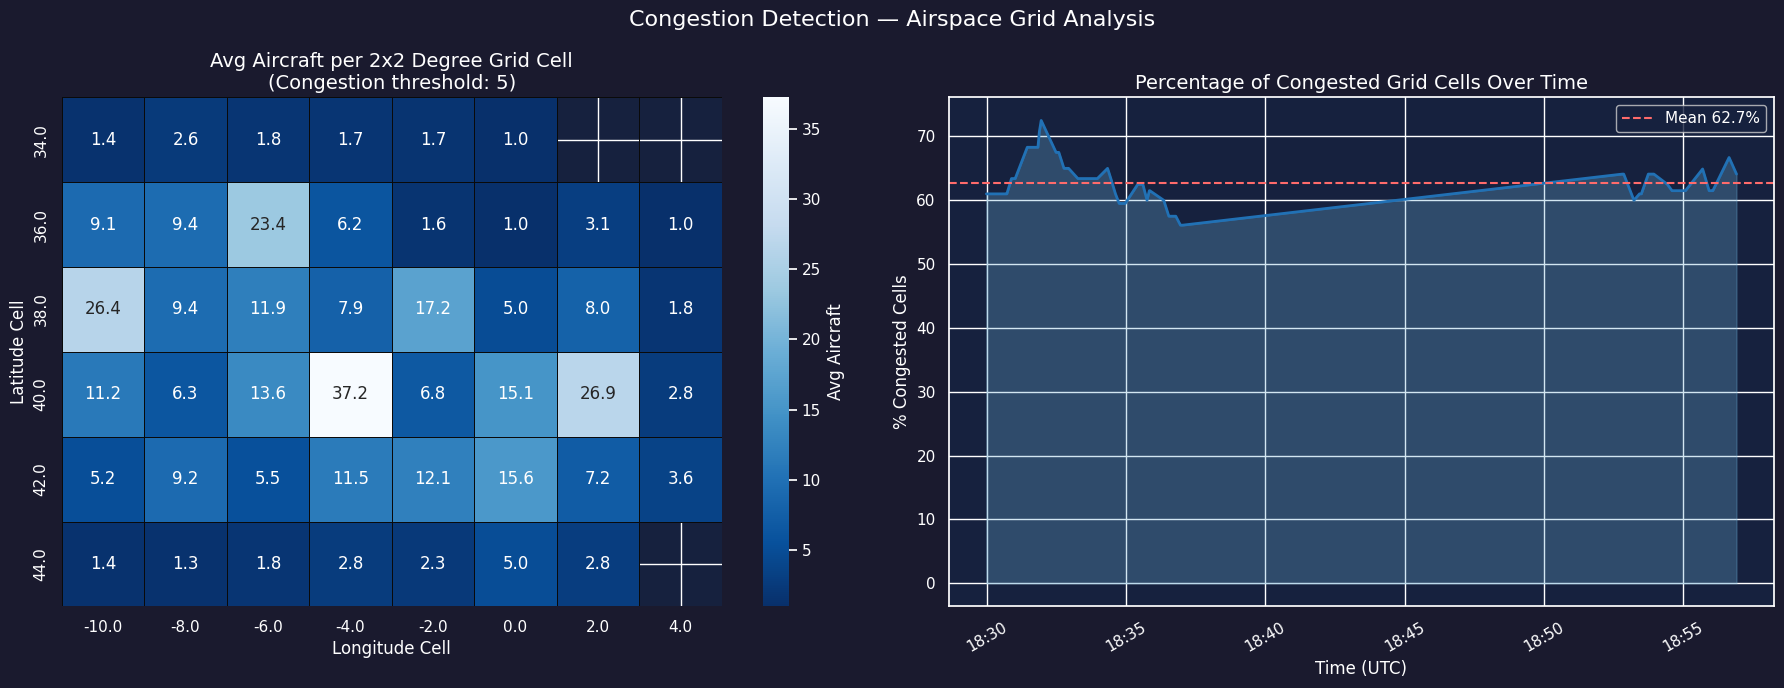

Chart saved: uc3_congestion.png


In [24]:
# Two-panel chart:
#   Left:  heatmap of average aircraft per grid cell (lat × lon)
#   Right: congestion percentage over time
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Congestion Detection — Airspace Grid Analysis', fontsize=16)

# Left panel — spatial heatmap
ax1 = axes[0]
heatmap_data = cluster_pd.pivot_table(
    index='lat_cell', columns='lon_cell', values='avg_aircraft', aggfunc='mean'
)
sns.heatmap(
    heatmap_data,
    ax=ax1,
    cmap='Blues_r',
    linewidths=0.5,
    linecolor='#0a0a0a',
    annot=True,
    fmt='.1f',
    cbar_kws={'label': 'Avg Aircraft'}
)
ax1.set_title(f'Avg Aircraft per 2x2 Degree Grid Cell\n(Congestion threshold: {CONGESTION_THRESHOLD})')
ax1.set_xlabel('Longitude Cell')
ax1.set_ylabel('Latitude Cell')

# Right panel — congestion timeline
ax2 = axes[1]
ax2.plot(cong_pd['snapshot_time'], cong_pd['congestion_pct'],
         color=sns.color_palette('Blues_r', 3)[0], linewidth=2)
ax2.fill_between(cong_pd['snapshot_time'], cong_pd['congestion_pct'],
                 alpha=0.3, color=sns.color_palette('Blues_r', 3)[1])
mean_pct = cong_pd['congestion_pct'].mean()
ax2.axhline(mean_pct, color='#ff6b6b', linestyle='--', label=f'Mean {mean_pct:.1f}%')
ax2.set_title('Percentage of Congested Grid Cells Over Time')
ax2.set_xlabel('Time (UTC)')
ax2.set_ylabel('% Congested Cells')
ax2.legend()
ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('uc3_congestion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: uc3_congestion.png')


### 3.7 — KMeans cluster scatter plot


Text(-9.5, 44.8, 'Monitored Region')

Text(0.5, 1.0, 'KMeans Density Clusters - Iberian Airspace (Bubble size proportional to avg aircraft in cell)')

Text(0.5, 0, 'Longitude (degrees)')

Text(0, 0.5, 'Latitude (degrees)')

(-15.0, 10.0)

(33.0, 47.0)

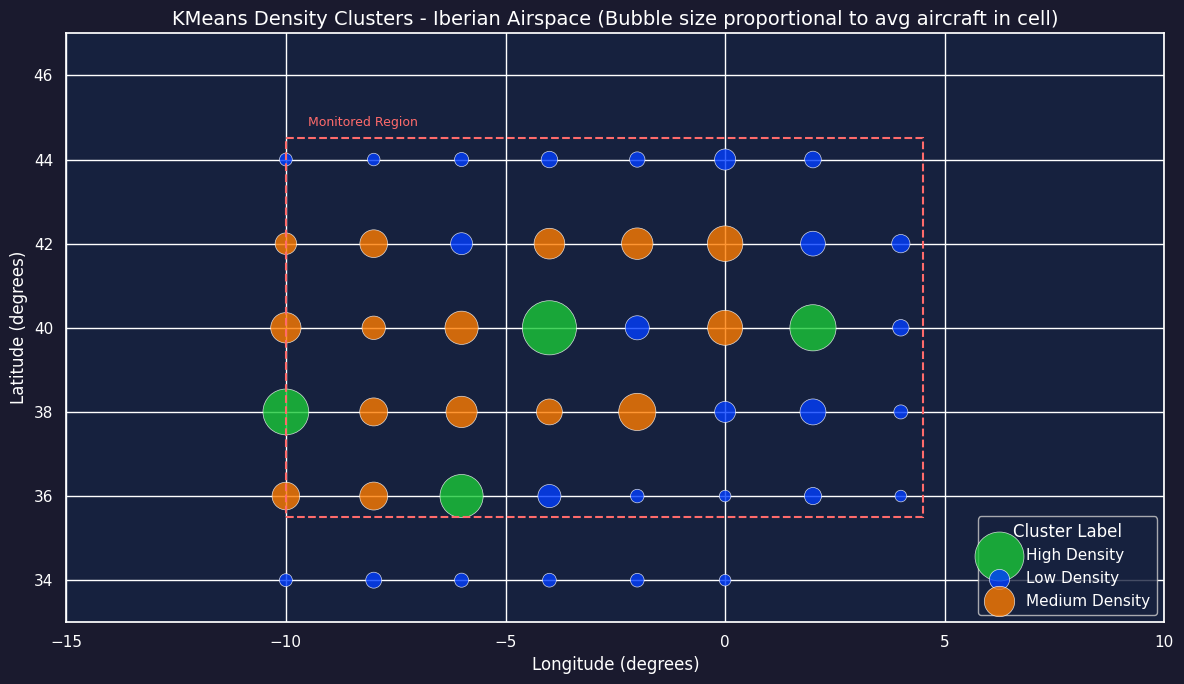

Chart saved: uc3_kmeans_clusters.png


In [26]:
fig, ax = plt.subplots(figsize=(12, 7))

palette_qual = sns.color_palette('bright', 3)
label_colors = {
    'Low Density':    palette_qual[0],
    'Medium Density': palette_qual[1],
    'High Density':   palette_qual[2]
}

for label, grp in cluster_pd.groupby('density_label'):
    ax.scatter(
        grp['lon_cell'], grp['lat_cell'],
        s=grp['avg_aircraft'] * 40 + 30,
        alpha=0.8,
        color=label_colors.get(label, 'white'),
        label=label,
        edgecolors='white',
        linewidths=0.5
    )

rect = plt.matplotlib.patches.Rectangle(
    (-10, 35.5), 14.5, 9, linewidth=1.5,
    edgecolor='#ff6b6b', facecolor='none', linestyle='--'
)
ax.add_patch(rect)
ax.text(-9.5, 44.8, 'Monitored Region', color='#ff6b6b', fontsize=9)

ax.set_title('KMeans Density Clusters - Iberian Airspace (Bubble size proportional to avg aircraft in cell)')
ax.set_xlabel('Longitude (degrees)')
ax.set_ylabel('Latitude (degrees)')
ax.legend(title='Cluster Label', loc='lower right')
ax.set_xlim(-15, 10)
ax.set_ylim(33, 47)

plt.tight_layout()
plt.savefig('uc3_kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: uc3_kmeans_clusters.png')

### 3.8 — Interactive map


In [27]:
# Create an interactive Folium map where each grid cell is drawn as a rectangle.
# Color indicates the KMeans density cluster; opacity scales with aircraft count.
m = folium.Map(
    location=[40.0, -3.5],
    zoom_start=6,
    tiles='CartoDB dark_matter'
)

color_map = {'Low Density': 'blue', 'Medium Density': 'orange', 'High Density': 'red'}

for _, row in cluster_pd.iterrows():
    color = color_map.get(row.get('density_label', 'Low Density'), 'blue')
    folium.Rectangle(
        bounds=[
            [row['lat_cell'],             row['lon_cell']],
            [row['lat_cell'] + GRID_SIZE, row['lon_cell'] + GRID_SIZE]
        ],
        color=color,
        fill=True,
        fill_opacity=min(row['avg_aircraft'] / 20, 0.8),
        weight=1,
        tooltip=(
            f"{row.get('density_label', '?')} | "
            f"Avg: {row['avg_aircraft']:.1f} aircraft | "
            f"Cell: {row['cell_id']}"
        )
    ).add_to(m)

m.save('uc3_interactive_map.html')
print('Interactive map saved: uc3_interactive_map.html')

Interactive map saved: uc3_interactive_map.html


**Insight — Congestion Detection**

KMeans successfully separates the airspace grid into three natural density zones.
High-density clusters concentrate along the main European airways passing over
northeastern Spain and the Mediterranean corridor.
The congestion timeline reveals that peak congestion is not constant — it spikes
during morning and afternoon waves that correspond to scheduled departure banks
at major European hubs.


---
<a id='summary'></a>
## Summary and Conclusions

| Use Case | Business Question | Spark Feature | Key Finding |
|----------|-------------------|---------------|-------------|
| 1 — Density Monitoring | How many aircraft fly at any given moment? | Structured Streaming | Traffic peaks mid-day UTC; streaming enables real-time alerting |
| 2 — Country/Airline Traffic | Which operators dominate the airspace? | Spark SQL | Spain leads domestic; transatlantic operators contribute significantly |
| 3 — Congestion Detection | Which zones are systematically congested? | Spark ML / KMeans | Three natural density clusters; northeastern corridor is consistently busiest |

**Potential future work**

- Add a Silver layer: cleaned and enriched Parquet files written back to MinIO  
- Add a Gold layer: pre-aggregated tables served from a database (e.g. PostgreSQL)  
- Extend the NiFi pipeline to ingest additional feeds (weather, NOTAMs) and join them in Spark  
- Deploy a live dashboard (e.g. Grafana) consuming the streaming results  
- Increase the grid resolution (0.5° cells) for finer congestion mapping  


## Cleanup


Stop the Spark session once all analysis is complete to release cluster resources.


In [28]:
spark.stop()
print('Spark session stopped. Analysis complete.')

Spark session stopped. Analysis complete.
